In [25]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# For balancing, scaling, splitting, and ANN
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics


In [27]:
df = pd.read_csv("Churn.csv")

In [29]:
print("Dataset Loaded Successfully")
print("\nShape of dataset:", df.shape)
print("\nColumns in dataset:\n", df.columns.tolist())

Dataset Loaded Successfully

Shape of dataset: (10000, 12)

Columns in dataset:
 ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


In [31]:
# Select input features and target output
x = df[['credit_score', 'age', 'tenure', 'balance',
        'products_number', 'credit_card', 'active_member',
        'estimated_salary']]

y = df['churn']

print("\nInput and Output Data Selected")
print("\nX shape:", x.shape)
print("\nY value counts:\n", y.value_counts())


Input and Output Data Selected

X shape: (10000, 8)

Y value counts:
 churn
0    7963
1    2037
Name: count, dtype: int64


In [33]:
# 4️⃣ Balance the Data using OverSampling
# -------------------------------
ros = RandomOverSampler(random_state=0)
x_res, y_res = ros.fit_resample(x, y)

print("\nData Balanced using RandomOverSampler")
print("\nBalanced Target Value Counts:\n", y_res.value_counts())


Data Balanced using RandomOverSampler

Balanced Target Value Counts:
 churn
1    7963
0    7963
Name: count, dtype: int64


In [35]:
# 5️⃣ Normalize Features using StandardScaler
# -------------------------------
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_res)

print("\nFeatures Normalized using StandardScaler")


Features Normalized using StandardScaler


In [37]:
# 6️⃣ Split Data (Train/Test)
# -------------------------------
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_res, random_state=0, test_size=0.25
)

print("\nData Split Completed")
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


Data Split Completed
Training Data Shape: (11944, 8)
Testing Data Shape: (3982, 8)


In [39]:
ann = MLPClassifier(hidden_layer_sizes=(100, 100, 100), 
                    random_state=0, 
                    max_iter=100, 
                    activation='relu')

ann.fit(x_train, y_train)

print("\nModel Training Completed")



Model Training Completed


C:\Users\omsaw\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [40]:
y_pred = ann.predict(x_test)

In [43]:
print("\nConfusion Matrix:")
cs = metrics.confusion_matrix(y_test, y_pred)
print(cs)

print("\nAccuracy Score:", metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred))


Confusion Matrix:
[[1630  351]
 [ 186 1815]]

Accuracy Score: 0.865143144148669

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86      1981
           1       0.84      0.91      0.87      2001

    accuracy                           0.87      3982
   macro avg       0.87      0.86      0.86      3982
weighted avg       0.87      0.87      0.86      3982



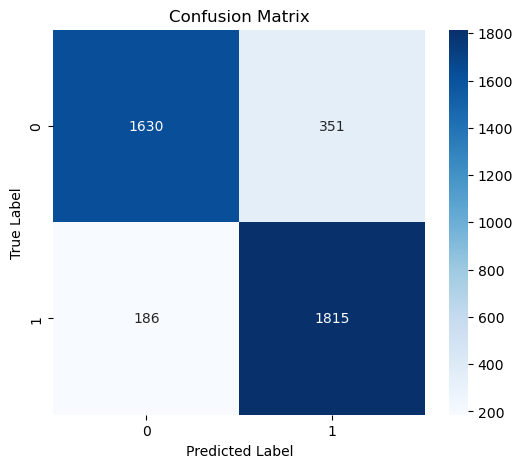

In [45]:
plt.figure(figsize=(6,5))
sns.heatmap(cs, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()